In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from transformers import AutoImageProcessor, ViTModel
from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image

2025-12-31 18:39:30.121551: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-31 18:39:30.121579: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-31 18:39:30.122435: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-31 18:39:30.127320: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-31 18:39:30.768122: W tensorflow/compiler/tf2

In [7]:
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root (folder containing '0_dataset_prep'). cwd={start}")

ROOT = find_dataset_root()

CSV_PATH   = ROOT / "0_dataset_prep" / "out" / "metadata" / "colonoscopy_metadata.csv"
IMG_DIR  = ROOT / "0_dataset_prep" / "out" / "images"    

df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head(3))

CSV shape: (42126, 7)
Columns: ['source', 'question', 'answer', 'img_id', 'question_norm', 'question_type', 'answer_type']
               source                                           question  \
0  Ulcerative Colitis  Are there any abnormalities in the image? Chec...   
1  Ulcerative Colitis  Are there any anatomical landmarks in the imag...   
2  Ulcerative Colitis  Are there any instruments in the image? Check ...   

               answer                     img_id  \
0  ulcerative colitis  cla820gl0s3nv071u4fgd7xgq   
1                none  cla820gl0s3nv071u4fgd7xgq   
2                none  cla820gl0s3nv071u4fgd7xgq   

                                       question_norm question_type answer_type  
0  are there any abnormalities in the image check...        Yes/No       Token  
1  are there any anatomical landmarks in the imag...        Yes/No     None/NA  
2  are there any instruments in the image check a...        Yes/No     None/NA  


Resolving img_id → image_path by trying common extensions, drop missing images

In [8]:
IMG_DIR = Path(IMG_DIR)
EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def resolve_img_path(img_id: str):
    for ext in EXTS:
        p = IMG_DIR / f"{img_id}{ext}"
        if p.exists():
            return str(p)
    return None

df["image_path"] = df["img_id"].apply(resolve_img_path)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)
print("After attaching paths:", df.shape)

After attaching paths: (42126, 8)


Creating answer_norm, keeps only yes/no rows, print counts

In [9]:
df["answer_norm"] = df["answer"].astype(str).str.strip().str.lower()
yn_df = df[df["answer_norm"].isin(["yes", "no"])].copy()

print("Yes/No subset:", yn_df.shape, Counter(yn_df["answer_norm"]))

Yes/No subset: (12267, 9) Counter({'yes': 6272, 'no': 5995})


In [10]:
MAX_PER_CLASS = 1200  # bump later if you want more data
balanced = []
for lab, grp in yn_df.groupby("answer_norm"):
    balanced.append(grp.sample(min(MAX_PER_CLASS, len(grp)), random_state=42))
yn_df = pd.concat(balanced).sample(frac=1, random_state=42).reset_index(drop=True)
print("Balanced subset:", yn_df.shape, Counter(yn_df["answer_norm"]))

Balanced subset: (2400, 9) Counter({'yes': 1200, 'no': 1200})


In [11]:
label_map = {"no": 0, "yes": 1}
yn_df["label"] = yn_df["answer_norm"].map(label_map)

train_df, test_df = train_test_split(
    yn_df[["image_path", "label", "question", "answer"]],
    test_size=0.2,
    random_state=42,
    stratify=yn_df["label"]
)
print("Train/Test sizes:", train_df.shape, test_df.shape)

Train/Test sizes: (1920, 4) (480, 4)


# CNN Baseline

Data Loading & Preprocessing - load_img_tf
Normalization: It divides pixel values by 255.0. This scales the pixel intensity from the range [0, 255] to [0, 1], which helps the model converge faster and remain stable during training.

Creating the Dataset Pipeline (make_ds)
map: Applies the load_img_tf function to every item in the dataset
batch: Groups images into stacks of 16 (BATCH_SIZE) to feed into the GPU at once.


In [13]:
TARGET_SIZE = (128, 128)
BATCH_SIZE  = 16
AUTOTUNE    = tf.data.AUTOTUNE

def load_img_tf(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, TARGET_SIZE)
    img = img / 255.0
    return img, label

def make_ds(frame, shuffle=False):
    paths = frame["image_path"].values
    labels = frame["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(frame), seed=42)
    ds = ds.map(load_img_tf, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, shuffle=True)
test_ds  = make_ds(test_df, shuffle=False)

cnn = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(2, activation="softmax")
])

cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("\n[ CNN ] training…")
cnn.fit(train_ds, validation_data=test_ds, epochs=2, verbose=1)


[ CNN ] training…
Epoch 1/2


2025-12-31 18:42:26.255256: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-12-31 18:42:26.255277: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: pop-os
2025-12-31 18:42:26.255281: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: pop-os
2025-12-31 18:42:26.255394: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 580.82.9
2025-12-31 18:42:26.255410: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  580.82.09  Release Build  (dvs-builder@U22-I3-C16-01-3)  Fri Aug 29 17:25:57 UTC 2025
GCC version:  gcc version 12.3.0 (Ubuntu 12.3.0-1ubuntu1~22.04

120/120 [==============================] - 4s 33ms/step - loss: 0.6100 - accuracy: 0.6313 - val_loss: 0.5449 - val_accuracy: 0.7063
Epoch 2/2
120/120 [==============================] - 4s 32ms/step - loss: 0.5265 - accuracy: 0.6880 - val_loss: 0.5007 - val_accuracy: 0.7021


Correct Predictions (The Diagonal):

True Negatives (Top-Left): 133 times, the image was "no" and the model correctly said "no".

True Positives (Bottom-Right): 202 times, the image was "yes" and the model correctly said "yes".

Errors (The Off-Diagonal):

False Positives (Top-Right): 107 times, the image was actually "no", but the model wrongly guessed "yes". (This is a high error rate).

False Negatives (Bottom-Left): 38 times, the image was "yes", but the model missed it and said "no".




[ CNN ] classification report
              precision    recall  f1-score   support

          no       0.87      0.47      0.61       240
         yes       0.64      0.93      0.76       240

    accuracy                           0.70       480
   macro avg       0.75      0.70      0.69       480
weighted avg       0.75      0.70      0.69       480



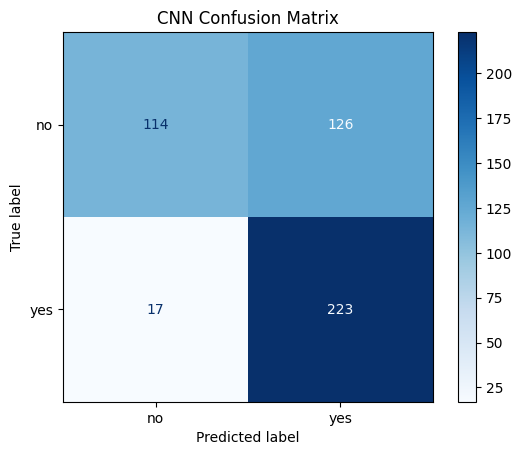

In [14]:
y_pred_cnn = np.argmax(cnn.predict(test_ds, verbose=0), axis=1)
y_true     = test_df["label"].values
print("\n[ CNN ] classification report")
print(classification_report(y_true, y_pred_cnn, target_names=["no","yes"]))
cm = confusion_matrix(y_true, y_pred_cnn)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("CNN Confusion Matrix"); plt.show()

acc_cnn = accuracy_score(y_true, y_pred_cnn)
f1_cnn  = f1_score(y_true, y_pred_cnn, average="macro")

# ViT + Logistic Regression

Built a Feature Extraction pipeline using a Vision Transformer (ViT) followed by a simple Logistic Regression classifier.

model used google/vit-base-patch16-224-in21k

vit_embed
It loops through the images in batches of 8.

torch.no_grad(): This tells PyTorch not to calculate gradients. This freezes the ViT model so it doesn't learn or change; it just predicts.

out = vit(**inp).last_hidden_state[:, 0, :]:
The ViT outputs a hidden state for every "patch" of the image
We are extracting just that one vector per image to use as our features.

The Classifier (LogisticRegression):

You feed those extracted vectors into a standard Scikit-Learn Logistic Regression model. This is very fast to train compared to a neural network.




[ ViT ] extracting frozen features… (sampling to keep it quick)


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.



[ ViT ] classification report
              precision    recall  f1-score   support

          no       0.71      0.68      0.69        93
         yes       0.73      0.76      0.74       107

    accuracy                           0.72       200
   macro avg       0.72      0.72      0.72       200
weighted avg       0.72      0.72      0.72       200



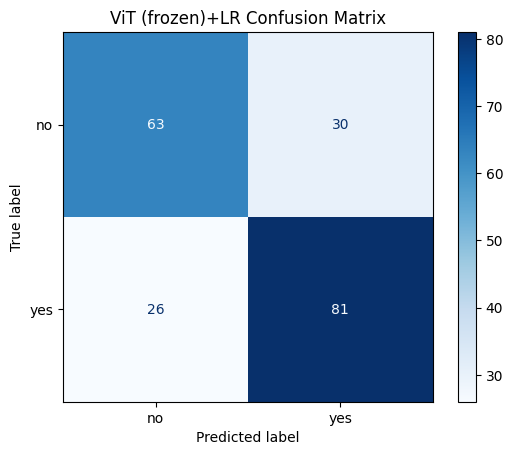

In [15]:
print("\n[ ViT ] extracting frozen features… (sampling to keep it quick)")
# To keep it fast on CPU, subsample
VIT_MAX = 800  # increase later if you want
train_v = train_df.sample(min(VIT_MAX, len(train_df)), random_state=42).reset_index(drop=True)
test_v  = test_df.sample(min(VIT_MAX//4, len(test_df)), random_state=42).reset_index(drop=True)

vit_name = "google/vit-base-patch16-224-in21k"
vit_proc = AutoImageProcessor.from_pretrained(vit_name)
vit      = ViTModel.from_pretrained(vit_name)

def vit_embed(paths):
    # returns CLS embeddings
    batch = []
    feats = []
    for p in paths:
        im = Image.open(p).convert("RGB")
        batch.append(vit_proc(images=im, return_tensors="pt"))
        if len(batch) == 8:
            inp = {k: torch.cat([b[k] for b in batch], dim=0) for k in batch[0]}
            with torch.no_grad():
                out = vit(**inp).last_hidden_state[:,0,:].numpy()
            feats.append(out)
            batch = []
    if batch:
        inp = {k: torch.cat([b[k] for b in batch], dim=0) for k in batch[0]}
        with torch.no_grad():
            out = vit(**inp).last_hidden_state[:,0,:].numpy()
        feats.append(out)
    return np.vstack(feats)

import torch
torch.set_grad_enabled(False)

X_train_vit = vit_embed(train_v["image_path"].tolist())
y_train_vit = train_v["label"].values
X_test_vit  = vit_embed(test_v["image_path"].tolist())
y_test_vit  = test_v["label"].values

clf_vit = LogisticRegression(max_iter=200, n_jobs=1)
clf_vit.fit(X_train_vit, y_train_vit)
y_pred_vit = clf_vit.predict(X_test_vit)

print("\n[ ViT ] classification report")
print(classification_report(y_test_vit, y_pred_vit, target_names=["no","yes"]))
cm = confusion_matrix(y_test_vit, y_pred_vit)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("ViT (frozen)+LR Confusion Matrix"); plt.show()

acc_vit = accuracy_score(y_test_vit, y_pred_vit)
f1_vit  = f1_score(y_test_vit, y_pred_vit, average="macro")

# BLIP VQA (zero/few-shot) mapped to yes/no

Unlike the previous ViT script, we are not training anything here

The Model (Salesforce/blip-vqa-base): BLIP is a famous multi-modal model designed to answer questions about images.

The Process followed here is:

We feed it the raw image.
WE feed it the specific question from our dataset (row["question"]).
we ask BLIP to generate a text answer.

We take BLIP's text output and check if it contains "yes" or "no".
Crucial Logic: If it contains neither, we default to 0 (No).

47% accuracy on a binary (yes/no) task is worse than a coin flip

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



[ BLIP VQA ] evaluating a small sample (maps to yes/no)

[ BLIP ] classification report
              precision    recall  f1-score   support

          no       0.48      0.38      0.42        61
         yes       0.47      0.58      0.52        59

    accuracy                           0.47       120
   macro avg       0.48      0.48      0.47       120
weighted avg       0.48      0.47      0.47       120



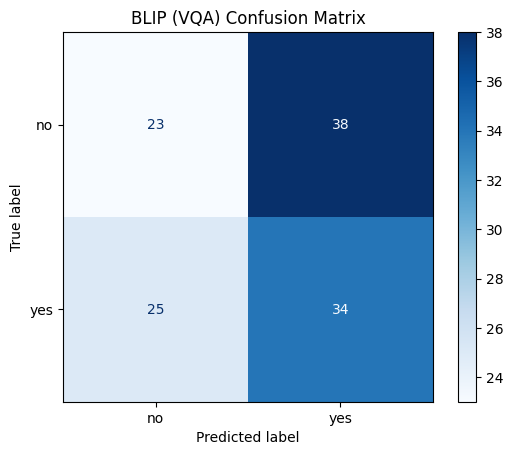

In [16]:
print("\n[ BLIP VQA ] evaluating a small sample (maps to yes/no)")
blip_name = "Salesforce/blip-vqa-base"
blip_proc = BlipProcessor.from_pretrained(blip_name)
blip      = BlipForQuestionAnswering.from_pretrained(blip_name)

BLIP_N = 120
sample_blip = test_df.sample(min(BLIP_N, len(test_df)), random_state=42).reset_index(drop=True)

def to_yesno(text):
    t = str(text).lower()
    if "yes" in t:
        return 1
    if "no" in t:
        return 0
    # fallback: default to 'no' if unclear
    return 0

preds_blip, true_blip = [], []
for _, row in sample_blip.iterrows():
    # Use the dataset question (works well for VQA)
    q = str(row["question"]) if isinstance(row["question"], str) and len(str(row["question"]).strip())>0 else "Is the answer yes or no?"
    im = Image.open(row["image_path"]).convert("RGB")
    inputs = blip_proc(images=im, text=q, return_tensors="pt")
    out = blip.generate(**inputs, max_new_tokens=10)
    txt = blip_proc.decode(out[0], skip_special_tokens=True)
    preds_blip.append(to_yesno(txt))
    true_blip.append(row["label"])

y_true_blip = np.array(true_blip)
y_pred_blip = np.array(preds_blip)

print("\n[ BLIP ] classification report")
print(classification_report(y_true_blip, y_pred_blip, target_names=["no","yes"]))
cm = confusion_matrix(y_true_blip, y_pred_blip)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("BLIP (VQA) Confusion Matrix"); plt.show()

acc_blip = accuracy_score(y_true_blip, y_pred_blip)
f1_blip  = f1_score(y_true_blip, y_pred_blip, average="macro")

# Comparison

In [17]:
results = pd.DataFrame([
    {"Model": "Tiny CNN (from scratch)", "Accuracy": acc_cnn, "Macro-F1": f1_cnn, "Notes": f"{len(train_df)} train / {len(test_df)} test"},
    {"Model": "ViT (frozen) + LR",       "Accuracy": acc_vit, "Macro-F1": f1_vit, "Notes": f"{len(train_v)} train / {len(test_v)} test (sampled)"},
    {"Model": "BLIP (VQA, zero-shot)",   "Accuracy": acc_blip,"Macro-F1": f1_blip,"Notes": f"{len(sample_blip)} VQA eval (sampled)"}
])
print("\n=== Comparison ===")
print(results.to_string(index=False))


=== Comparison ===
                  Model  Accuracy  Macro-F1                          Notes
Tiny CNN (from scratch)  0.702083  0.685885          1920 train / 480 test
      ViT (frozen) + LR  0.720000  0.717713 800 train / 200 test (sampled)
  BLIP (VQA, zero-shot)  0.475000  0.470551         120 VQA eval (sampled)


## Conclusion

Best (in this notebook): ViT frozen features + LR slightly beats tiny CNN on balanced yes/no.

BLIP zero-shot performs poorly for direct yes/no classification via naive text→label mapping.

Current comparison is not apples-to-apples (different sample sizes: 480 vs 200 vs 120).